# Baseline Metrics: Diversity, Perplexity, Coherence, Q*Text

- Single-text automatic metrics from the open-ended text generation literature
- External baselines to contextualize diversity vector
- Definitions from Garces Arias et al., 2025: Towards Better Open-Ended Text Generation: A Multicriteria Evaluation Framework

| Metric | Formula | Direction |
|---|---|---|
| Diversity | $\text{DIV}(x) = \prod_{n=2}^{4} \dfrac{\lvert\text{unique } n\text{-grams}(x)\rvert}{\lvert\text{total } n\text{-grams}(x)\rvert}$ | higher = more lexically varied |
| Perplexity | $P(W) = \exp\left(-\dfrac{1}{N}\sum_{i=1}^N \log p(w_i \mid w_1,\dots,w_{i-1})\right)$ | lower = more predictable/fluent |
| Coherence | $\text{Coherence}(\hat x, x) = \dfrac{1}{\lvert\hat x\rvert}\sum_{i=1}^{\lvert\hat x\rvert}\log p_M(\hat x_i \mid [x:\hat x_{<i}])$ | higher = better conditioned on prompt |
| Q*Text | $\dfrac{\sum_{i=1}^{3} w_i M_i P_i(M_i)}{\sum_{i=1}^{3} w_i}$, with $P_i(x)=\exp(-\alpha_i(x-\mu_i)^2)$ | 0–100, weighted combination of the three metrics above |

**Deviations from the paper:**
- **OPT-2.7B** as a single shared scorer for both Coherence and Perplexity (paper itself fits each metric with a different scorer (OPT-2.7B is the one it uses for Coherence))
- Q*Text reuses the paper's published fitted parameters rather than refitting them on this data

### Data
Generated data from `data_generation/generations/` switchable via `DOMAIN`:
- **`storytelling_n200`**: WritingPrompts (Fan et al., 2018) test split, 200 prompts x 4 LLMs x 5 samples + >=5 human reference stories/prompt
- **`translation_ref3`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=3 human translations/paragraph
- **`translation_ref4`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=4 human translations/paragraph

Coherence conditions on the writing prompt (`storytelling_n200`) or the source-language paragraph (translation domains).

In [1]:
# Load libraries
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/Masterthesis/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Print-oriented plotting defaults: figures are sized close to their intended print width

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10})

tqdm.pandas()

In [3]:
# Configuration
DOMAIN = 'translation_ref3'  # 'storytelling_n200', 'translation_ref3' or 'translation_ref4'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200

DOMAIN_CONFIG = {
    'storytelling_n200': dict(
        data_dir='storytelling_n200',
        gen_file=lambda key: f'writingprompts_{key}_n5.jsonl',
        prompts_file='prompts_sample.jsonl',
        text_field='story',
        human_field='human_stories',
        prompt_field='prompt',
    ),
    'translation_ref3': dict(
        data_dir='translation_ref3',
        gen_file=lambda key: f'par3_{key}_n5.jsonl',
        prompts_file='par3_paragraphs_sample.jsonl',
        text_field='translation',
        human_field='human_translations',
        prompt_field='source_text',
    ),
    'translation_ref4': dict(
        data_dir='translation_ref4',
        gen_file=lambda key: f'par3_{key}_n5.jsonl',
        prompts_file='par3_paragraphs_sample.jsonl',
        text_field='translation',
        human_field='human_translations',
        prompt_field='source_text',
    ),
}

In [4]:
MODEL_LABELS = {
    'human': 'Human', 'gemma': 'Gemma-2-9B', 'llama': 'Llama-3.1-8B',
    'mistral': 'Mistral-7B-v0.3', 'qwen': 'Qwen2.5-7B',
}
MODEL_COLORS = {
    'Human':            '#cb1f73',
    'Gemma-2-9B':       '#fcc72d',
    'Llama-3.1-8B':     '#ea6d3d',
    'Mistral-7B-v0.3':  '#e03a3c',
    'Qwen2.5-7B':       '#383a6b',
}
MODEL_ORDER = ['Human', 'Gemma-2-9B', 'Llama-3.1-8B', 'Mistral-7B-v0.3', 'Qwen2.5-7B']

FIG_DIR = Path(f'../../figures/baseline_metrics/{DOMAIN}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path(f'../../metrics/04_baseline_metrics/tables/{DOMAIN}')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'facebook/opt-2.7b'   # shared scorer for Coherence & Perplexity, matches the paper's own Coherence scorer
MODEL_TAG = MODEL_NAME.split('/')[-1]  # short tag for cache/output filenames, e.g. 'opt-2.7b'
MAX_TOKENS = 256                   # matches the paper's generation length cap
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

print('Configuration:')
print(f'  Domain:     {DOMAIN}')
print(f'  Sources:    {SOURCES}')
print(f'  Scorer:     {MODEL_NAME} on {DEVICE}')
print(f'  Max tokens: {MAX_TOKENS}')

Configuration:
  Domain:     translation_ref3
  Sources:    ['human', 'llama', 'mistral', 'qwen', 'gemma']
  Scorer:     facebook/opt-2.7b on mps
  Max tokens: 256


## Load Dataset

In [5]:
# Repo root importable regardless of the kernel's working directory
def find_repo_root(start=None):
    start = Path(start or Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/')")


# Load the prompt texts and human reference texts for the selected domain plus the generated texts
REPO_ROOT = find_repo_root()
cfg = DOMAIN_CONFIG[DOMAIN]
DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / cfg['data_dir']
print(f"DOMAIN = {DOMAIN!r}  ({DATA_DIR})")

# Prompt order + human reference texts + prompt text (conditioning context for Coherence),
# from the shared prompts file (one row per prompt/paragraph)
prompt_ids, human_raw, prompt_texts = [], {}, {}

with open(DATA_DIR / cfg['prompts_file']) as f:
    for line in f:
        # Load the prompt ID, human reference texts and prompt text from the JSONL file
        r = json.loads(line)
        prompt_ids.append(r['prompt_id'])
        human_raw[r['prompt_id']] = r[cfg['human_field']]
        prompt_texts[r['prompt_id']] = r[cfg['prompt_field']]

# Limit to the first N_PROMPTS prompts (for consistency with the paper's evaluation)
prompt_ids = prompt_ids[:N_PROMPTS]
prompt_index = {pid: i for i, pid in enumerate(prompt_ids)}

rows = []

# Load the human reference texts (one row per prompt x story)
for pid, i in prompt_index.items():
    val = human_raw[pid]
    human_texts = list(val.values()) if isinstance(val, dict) else list(val)

    # Add each human reference text to the rows list with its corresponding prompt ID, source, story ID, prompt text, and text
    for story_id, text in enumerate(human_texts):
        rows.append({'prompt_id': i, 'source': 'human', 'story_id': story_id, 'prompt': prompt_texts[pid], 'text': text})

# Generated texts per model (4 LLMs x N_PROMPTS x 5 samples)
# Filter out any generated texts that were dropped due to quality issues (e.g., exceeding length or failing language checks)
n_dropped = {}
for source in SOURCES:
    if source == 'human':
        continue
    dropped, story_counters = 0, {}
    with open(DATA_DIR / cfg['gen_file'](source)) as f:
        for line in f:

            # Load the generated text's prompt ID and check if it is in the prompt index
            r = json.loads(line)
            pid = r['prompt_id']

            if pid not in prompt_index:
                continue

            # Drop any generated texts that were dropped due to quality issues (e.g., exceeding length or failing language checks)
            if r.get('finish_reason') == 'length' or not r.get('language_ok', True):
                dropped += 1
                continue

            # Add the generated text to the rows list with its corresponding prompt ID, source, story ID, prompt text and text
            i = prompt_index[pid]
            story_id = story_counters.get(i, 0)

            rows.append({'prompt_id': i, 'source': source, 'story_id': story_id,
                          'prompt': prompt_texts[pid], 'text': r[cfg['text_field']]})
            
            story_counters[i] = story_id + 1
    n_dropped[source] = dropped

df = pd.DataFrame(rows)
df['model'] = df['source'].map(MODEL_LABELS)


print(f'Loaded: {len(df)} texts ({df["prompt_id"].nunique()} prompts x {len(SOURCES)} sources)')
print(f'Dropped (quality filter): {n_dropped}')
print(df.groupby('source').size())
df.head(3)

DOMAIN = 'translation_ref3'  (/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/Masterthesis/data_generation/generations/translation_ref3)
Loaded: 4403 texts (200 prompts x 5 sources)
Dropped (quality filter): {'llama': 9, 'mistral': 27, 'qwen': 166, 'gemma': 64}
source
gemma      936
human      669
llama      991
mistral    973
qwen       834
dtype: int64


,prompt_id,source,story_id,prompt,text,model
0,0,human,0,"Впрочем, что ж я? — все это делают; болезнями-...",Though – what am I saying? – everyone does it;...,Human
1,0,human,1,"Впрочем, что ж я? — все это делают; болезнями-...","Why do I say that, though? Everybody does it –...",Human
2,0,human,2,"Впрочем, что ж я? — все это делают; болезнями-...","But, gentlemen, whoever can pride himself on h...",Human


## Diversity: n-gram Repetition Rates

$$\text{DIV}(x) = \prod_{n=2}^{4} \frac{|\text{unique } n\text{-grams}(x)|}{|\text{total } n\text{-grams}(x)|}$$

- Purely lexical, no model needed
- Word tokens via simple regex (`\w+`, lowercased), consistent with the standard distinct-*n* family of diversity metrics

In [6]:
# Word tokenizer
def word_tokenize_simple(text):
    return re.findall(r"\w+", text.lower())

def diversity_score(text, n_range=(2, 3, 4)):
    '''Calculate the diversity score of a text based on unique n-grams for n in n_range.'''
    tokens = word_tokenize_simple(text)
    score = 1.0

    for n in n_range:
        # Only consider n-grams if there are enough tokens
        if len(tokens) < n:
            return np.nan
    
        # Create n-grams
        ngrams = list(zip(*(tokens[i:] for i in range(n))))
        unique = len(set(ngrams))
        
        # Calculate the diversity score as the ratio of unique n-grams to total n-grams
        score *= unique / len(ngrams)
    return score


df['Diversity'] = df['text'].progress_apply(diversity_score)
print(df['Diversity'].describe())

100%|██████████| 4403/4403 [00:00<00:00, 8295.46it/s]

count    4403.000000
mean        0.880684
std         0.113185
min         0.009203
25%         0.859199
50%         0.902025
75%         0.937437
max         1.000000
Name: Diversity, dtype: float64


## Load the Fixed External Scorer (OPT-2.7B)

In [7]:
# float16 on MPS/GPU to keep the 2.7B-parameter model's memory footprint manageable (CPU stays float32)
SCORER_DTYPE = torch.float16 if DEVICE.type != 'cpu' else torch.float32

# Load the shared OPT-2.7B model for scoring Coherence and Perplexity
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=SCORER_DTYPE).to(DEVICE)
model.eval()

# Context-window field differs by architecture (GPT-2: n_positions, OPT/most others: max_position_embeddings)
CTX_LIMIT = getattr(model.config, 'n_positions', None) or model.config.max_position_embeddings
print(f'{MODEL_NAME} loaded on {DEVICE} ({SCORER_DTYPE}, context window: {CTX_LIMIT} tokens)')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 517/517 [00:00<00:00, 79550.06it/s]


facebook/opt-2.7b loaded on mps (torch.float16, context window: 2048 tokens)


## Perplexity: Self-Predictability of the Continuation

- Computed on generated text alone (no prompt context), truncated to `MAX_TOKENS`
- Uses OPT-2.7B's built-in cross-entropy loss ( = mean negative log-likelihood over the shifted sequence)

In [8]:
# Compute perplexity using the scorer model
@torch.no_grad()
def compute_perplexity(text, max_tokens=MAX_TOKENS):
    ''' Compute the perplexity of a text using the scorer model. Returns NaN if the text is too short.'''

    # Input text to model and compute loss
    input_ids = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_tokens)['input_ids'].to(DEVICE)

    # Only compute perplexity if the text has at least 2 tokens
    if input_ids.shape[1] < 2:
        return np.nan

    # Compute the loss and convert it to perplexity
    loss = model(input_ids, labels=input_ids).loss

    return float(torch.exp(loss).cpu())

# Load or compute perplexity (cached per domain + scorer model, since both affect the result)
CACHE_PATH = TABLE_DIR / f'baseline_metrics_results_{MODEL_TAG}.csv'
KEY_COLS = ['prompt_id', 'source', 'story_id']

# Load cached perplexity if available, otherwise compute it for each text
if CACHE_PATH.exists():
    cached = pd.read_csv(CACHE_PATH)[KEY_COLS + ['Perplexity']]
    df = df.merge(cached, on=KEY_COLS, how='left')
    print(f'Loaded cached Perplexity for {df["Perplexity"].notna().sum()}/{len(df)} texts (skipped recomputation)')

else:
    df['Perplexity'] = df['text'].progress_apply(compute_perplexity)

print(df['Perplexity'].describe())

100%|██████████| 4403/4403 [52:20<00:00,  1.40it/s]

count    4403.000000
mean       24.296796
std         9.034556
min         5.900095
25%        18.164801
50%        22.578604
75%        28.598854
max        97.792664
Name: Perplexity, dtype: float64


## Coherence: Log-Likelihood of the Continuation Given the Prompt

$$\text{Coherence}(\hat x, x) = \frac{1}{|\hat x|}\sum_{i=1}^{|\hat x|} \log p_M(\hat x_i \mid [x : \hat x_{<i}])$$

- Prompt and continuation are each truncated to `MAX_TOKENS` & concatenated    
-> Only the log-probabilities of the continuation tokens (conditioned on the prompt) are averaged
- Conditioning text $x$ is the writing prompt for `storytelling_n200` or the source-language paragraph (`source_text`) for translation

In [9]:
@torch.no_grad()
def compute_coherence(prompt, text, max_tokens=MAX_TOKENS):
    ''' Compute the coherence of a text given a prompt using the scorer model. Returns NaN if the text is too short.'''

    # Tokenize the prompt
    prompt_ids = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=max_tokens)['input_ids']

    # Tokenize the continuation text and check if it has at least 1 token.
    # add_special_tokens=False: some tokenizers (e.g. OPT's, which prepends </s> as BOS) would
    # otherwise insert a spurious special token right at the prompt/continuation boundary below
    cont_ids = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_tokens,
                          add_special_tokens=False)['input_ids']

    # Only compute coherence if the continuation has at least 1 token
    if cont_ids.shape[1] < 1:
        return np.nan

    # Concatenate prompt and continuation
    input_ids = torch.cat([prompt_ids, cont_ids], dim=1)
    prompt_len = prompt_ids.shape[1]

    # Ensure the input does not exceed the model's context window
    ctx_limit = CTX_LIMIT
    if input_ids.shape[1] > ctx_limit:

        # Truncate the input to fit within the context window, keeping the last `ctx_limit` tokens
        overflow = input_ids.shape[1] - ctx_limit
        input_ids = input_ids[:, overflow:]
        prompt_len = max(prompt_len - overflow, 0)

    # Compute the log probabilities of the continuation tokens given the prompt
    input_ids = input_ids.to(DEVICE)
    logits = model(input_ids).logits
    log_probs = torch.log_softmax(logits[:, :-1, :], dim=-1)

    # Gather the log probabilities of the continuation tokens (excluding the prompt tokens)
    targets = input_ids[:, 1:]
    token_log_probs = log_probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)

    # Compute the mean log probability of the continuation tokens
    cont_start = max(prompt_len - 1, 0)
    cont_log_probs = token_log_probs[:, cont_start:]

    # Return NaN if the continuation has no tokens (e.g., if the prompt was too long and truncated the continuation)
    if cont_log_probs.shape[1] == 0:
        return np.nan
    
    return float(cont_log_probs.mean().cpu())


# Load or compute coherence (same per-domain + per-scorer cache as Perplexity)
if CACHE_PATH.exists():
    cached = pd.read_csv(CACHE_PATH)[KEY_COLS + ['Coherence']]
    df = df.merge(cached, on=KEY_COLS, how='left')

    print(f'Loaded cached Coherence for {df["Coherence"].notna().sum()}/{len(df)} texts (skipped recomputation)')

else:
    df['Coherence'] = df.progress_apply(lambda r: compute_coherence(r['prompt'], r['text']), axis=1)
    
print(df['Coherence'].describe())

100%|██████████| 4403/4403 [1:51:40<00:00,  1.52s/it]  

count    4403.000000
mean       -2.859462
std         0.448614
min        -4.613281
25%        -3.171875
50%        -2.892578
75%        -2.560547
max        -0.801270
Name: Coherence, dtype: float64


## Save Results

In [10]:
df[['prompt_id', 'source', 'story_id', 'model', 'Diversity', 'Perplexity', 'Coherence']].to_csv(
    TABLE_DIR / f'baseline_metrics_results_summary_{MODEL_TAG}.csv', index=False
)

df.to_csv(CACHE_PATH, index=False)

print(f'Saved baseline metrics to: {CACHE_PATH}')

df.head(5)

Saved baseline metrics to: ../../metrics/04_baseline_metrics/tables/translation_ref3/baseline_metrics_results_opt-2.7b.csv


,prompt_id,source,story_id,prompt,text,model,Diversity,Perplexity,Coherence
0,0,human,0,"Впрочем, что ж я? — все это делают; болезнями-...",Though – what am I saying? – everyone does it;...,Human,0.848682,21.141619,-2.962891
1,0,human,1,"Впрочем, что ж я? — все это делают; болезнями-...","Why do I say that, though? Everybody does it –...",Human,0.860112,14.365216,-2.595703
2,0,human,2,"Впрочем, что ж я? — все это делают; болезнями-...","But, gentlemen, whoever can pride himself on h...",Human,0.853709,19.953869,-2.949219
3,1,human,0,K. wartete während der nächsten Woche von Tag ...,K. waited from day to day throughout the follo...,Human,0.953191,13.986429,-2.253906
4,1,human,1,K. wartete während der nächsten Woche von Tag ...,DURING the next week K. waited day after day f...,Human,0.917938,20.588316,-2.564453


## Descriptive Analysis by Source

In [11]:
METRICS = ['Diversity', 'Perplexity', 'Coherence']

summary = df.groupby('source')[METRICS].agg(['mean', 'std']).round(3)
summary = summary.loc[SOURCES]
summary.index = [MODEL_LABELS[s] for s in SOURCES]
summary

Diversity        Perplexity        Coherence       
                     mean    std       mean    std      mean    std
Human               0.901  0.058     20.660  8.274    -2.792  0.400
Llama-3.1-8B        0.884  0.065     24.872  9.123    -2.882  0.442
Mistral-7B-v0.3     0.833  0.203     27.062  9.272    -2.952  0.479
Qwen2.5-7B          0.898  0.064     24.084  8.671    -2.827  0.431
Gemma-2-9B          0.897  0.059     23.602  8.520    -2.818  0.455

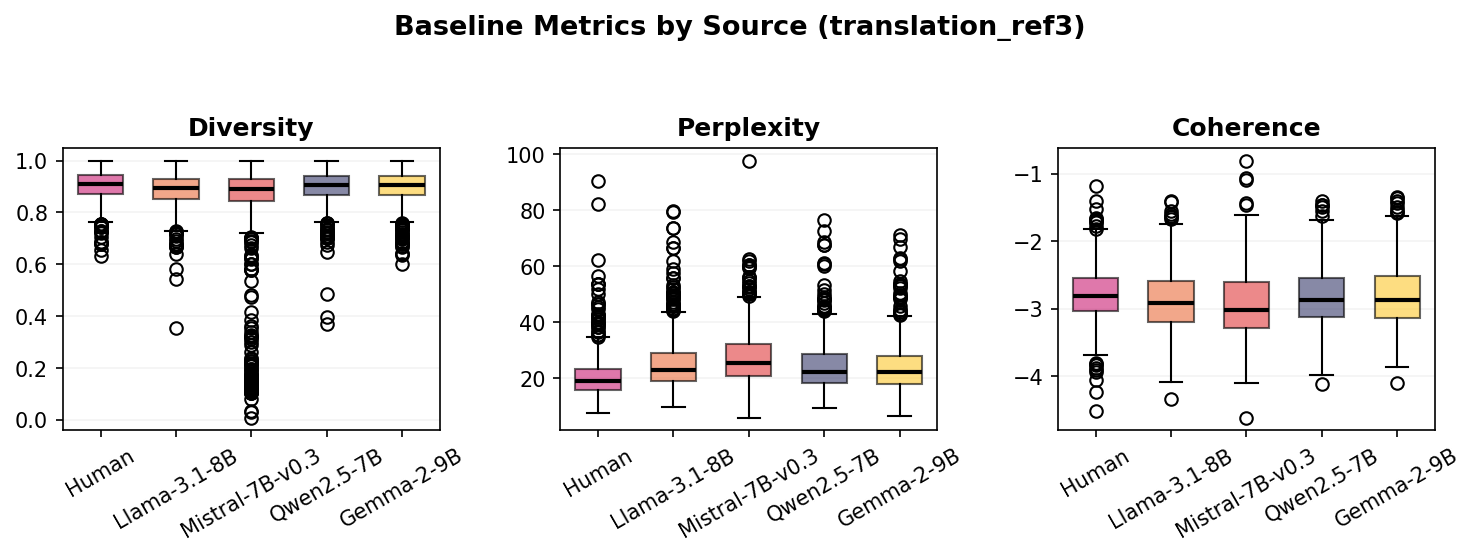

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

labels_plot = [MODEL_LABELS[s] for s in SOURCES]
colors_plot = [MODEL_COLORS[l] for l in labels_plot]

for ax, metric in zip(axes, METRICS):
    data_plot = [df[df['source'] == s][metric].dropna().values for s in SOURCES]
    bp = ax.boxplot(data_plot, labels=labels_plot, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2), widths=0.6)

    for patch, color in zip(bp['boxes'], colors_plot):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')

fig.suptitle(f'Baseline Metrics by Source ({DOMAIN})', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_metrics_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print('Kruskal-Wallis Test: Baseline Metric Differences across Sources\n')
print(f'{"Metric":<12} {"H-stat":>10} {"p-value":>12}')
print('-' * 58)

for metric in METRICS:
    groups = [df[df['source'] == s][metric].dropna().values for s in SOURCES]
    stat, p = kruskal(*groups)
    
    print(f'{metric:<12} {stat:>10.2f} {p:>12.4f}')

Kruskal-Wallis Test: Baseline Metric Differences across Sources

Metric           H-stat      p-value
----------------------------------------------------------
Diversity         74.82       0.0000
Perplexity       294.40       0.0000
Coherence         79.88       0.0000


## Metric Intercorrelations

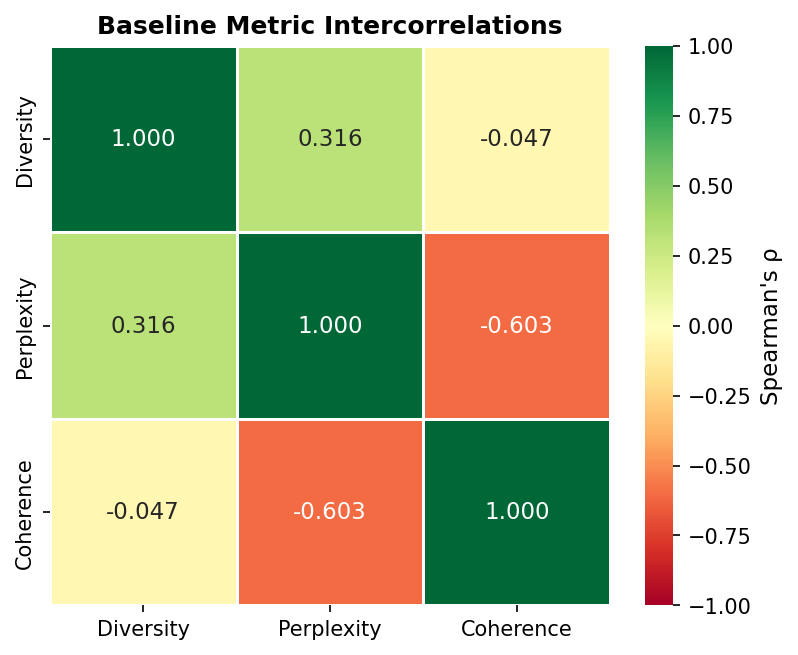

In [14]:
corr_df = df[METRICS].dropna()
rho_matrix = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(rho_matrix, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman's ρ"})
ax.set_title('Baseline Metric Intercorrelations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_metrics_intercorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

## Q*Text: Unified Quality Score (Garces Arias et al., 2025)

$$\text{Q*Text} = \frac{\sum_{i=1}^{3} w_i M_i P_i(M_i)}{\sum_{i=1}^{3} w_i}, \qquad P_i(x) = \exp(-\alpha_i (x-\mu_i)^2)$$

- $M_1, M_2, M_3$ are Perplexity, Coherence and Diversity, each min-max normalized to $[0,1]$ over this dataset (Perplexity inverted so higher = better)
- $w_i$, $\mu_i$, $\alpha_i$ are weights, target values and penalty strengths per metric
- Result ×100 to match the paper's reported score range

**Parameters (paper's own fitted values)**:

| | Perplexity ($i=1$) | Coherence ($i=2$) | Diversity ($i=3$) |
|---|---|---|---|
| $w_i$ | 0.586 | 0.834 | 3.853 |
| $\mu_i$ | 0.458 | 0.000 | 0.854 |
| $\alpha_i$ | 2.579 | 1.496 | 7.370 |

In [15]:
# Fitted hyperparameters from Garces Arias et al. (2025), Table 21
Q_STAR_PARAMS = {
    # order in each tuple: (Perplexity, Coherence, Diversity)
    'w':     (0.586, 0.834, 3.853),   # weight: how much each metric contributes to the final score
    'mu':    (0.458, 0.000, 0.854),   # target: the "ideal" normalized value for each metric
    'alpha': (2.579, 1.496, 7.370),   # penalty strength: how sharply the score drops away from mu
}


def gaussian_penalty(x, mu, alpha):
    """P_i(x) = exp(-alpha * (x - mu)^2).

    - Equals 1.0 at x == mu and decays towards 0 the further x is from mu.
    - Large alpha -> narrow peak (strict), small alpha -> wide peak (lenient).
    """
    return np.exp(-alpha * (x - mu) ** 2)


def compute_qstar(perplexity, coherence, diversity, params=Q_STAR_PARAMS):
    # Step 1: normalize each raw metric to [0, 1] over the current dataset (dataset-relative
    # min-max, exactly as in the paper), so all three become directly comparable and
    # "higher = better" for all of them

    p_min, p_max = perplexity.min(), perplexity.max()
    c_min, c_max = coherence.min(), coherence.max()
    d_min, d_max = diversity.min(), diversity.max()

    m1 = (p_max - perplexity) / (p_max - p_min)   # Perplexity: raw LOWER is better -> flip direction
    m2 = (coherence - c_min) / (c_max - c_min)     # Coherence: raw higher is better -> standard min-max
    m3 = (diversity - d_min) / (d_max - d_min)     # Diversity: raw higher is better -> standard min-max

    w1, w2, w3 = params['w']
    mu1, mu2, mu3 = params['mu']
    a1, a2, a3 = params['alpha']

    # Step 2: apply the Gaussian penalty to each normalized metric
    p1 = gaussian_penalty(m1, mu1, a1)
    p2 = gaussian_penalty(m2, mu2, a2)
    p3 = gaussian_penalty(m3, mu3, a3)

    # Step 3: weighted average of (metric value * its own penalty). 
    numerator = w1 * m1 * p1 + w2 * m2 * p2 + w3 * m3 * p3

    # Multiplying by 100 matches the score range reported in the paper
    return 100 * numerator / (w1 + w2 + w3)

# Compute Q*Text for each text in the dataset
df['QStarText'] = compute_qstar(df['Perplexity'], df['Coherence'], df['Diversity'])

print(df['QStarText'].describe())

count    4403.000000
mean       73.065319
std         9.546982
min         0.543116
25%        73.849034
50%        75.709601
75%        76.484226
max        77.369570
Name: QStarText, dtype: float64


In [16]:
# Overwrite the results CSVs
df.to_csv(CACHE_PATH, index=False)

df[['prompt_id', 'source', 'story_id', 'model', 'Diversity', 'Perplexity', 'Coherence', 'QStarText']].to_csv(
    TABLE_DIR / f'baseline_metrics_results_summary_{MODEL_TAG}.csv', index=False
)
print('Updated baseline_metrics_results.csv / _summary.csv with QStarText')

Updated baseline_metrics_results.csv / _summary.csv with QStarText


In [17]:
# Mean/std of all four metrics per source
ALL_METRICS = METRICS + ['QStarText']

summary_q = df.groupby('source')[ALL_METRICS].agg(['mean', 'std']).round(3)
summary_q = summary_q.loc[SOURCES]
summary_q.index = [MODEL_LABELS[s] for s in SOURCES]
summary_q

Diversity        Perplexity        Coherence        QStarText  \
                     mean    std       mean    std      mean    std      mean   
Human               0.901  0.058     20.660  8.274    -2.792  0.400    74.564   
Llama-3.1-8B        0.884  0.065     24.872  9.123    -2.882  0.442    73.682   
Mistral-7B-v0.3     0.833  0.203     27.062  9.272    -2.952  0.479    68.916   
Qwen2.5-7B          0.898  0.064     24.084  8.671    -2.827  0.431    74.438   
Gemma-2-9B          0.897  0.059     23.602  8.520    -2.818  0.455    74.432   

                         
                    std  
Human             4.015  
Llama-3.1-8B      5.289  
Mistral-7B-v0.3  17.586  
Qwen2.5-7B        5.113  
Gemma-2-9B        4.437

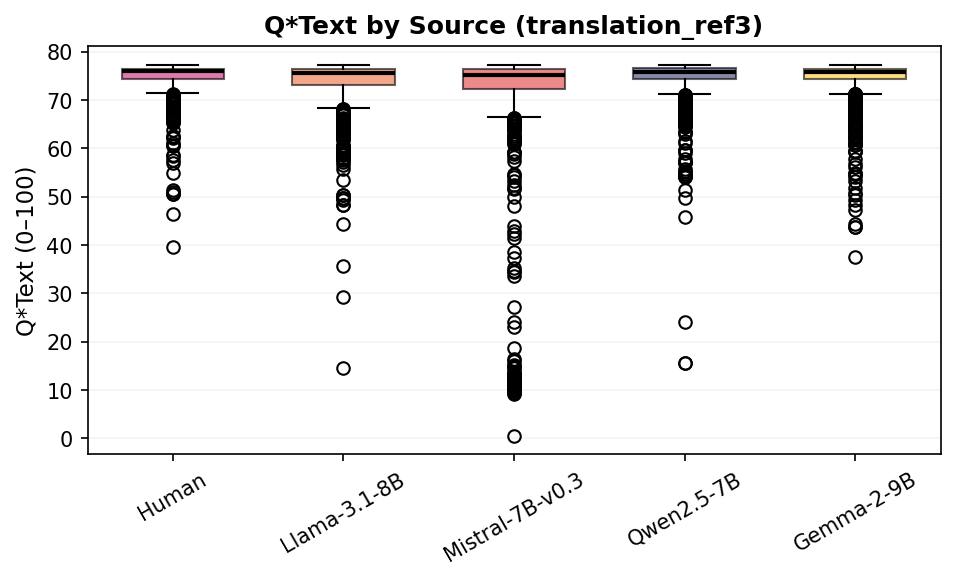

In [18]:
# Boxplot of Q*Text per source

fig, ax = plt.subplots(figsize=(6.5, 4))
labels_plot = [MODEL_LABELS[s] for s in SOURCES]
colors_plot = [MODEL_COLORS[l] for l in labels_plot]
data_plot = [df[df['source'] == s]['QStarText'].dropna().values for s in SOURCES]

bp = ax.boxplot(data_plot, labels=labels_plot, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2), widths=0.6)

for patch, color in zip(bp['boxes'], colors_plot):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title(f'Q*Text by Source ({DOMAIN})', fontsize=12, fontweight='bold')
ax.set_ylabel('Q*Text (0–100)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'qstartext_by_source.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Significance test for Q*Text across sources (Kruskal-Wallis tests)
groups = [df[df['source'] == s]['QStarText'].dropna().values for s in SOURCES]
stat, p = kruskal(*groups)


print('Kruskal-Wallis Test: Q*Text Differences across Sources\n')
print(f'{"Metric":<12} {"H-stat":>10} {"p-value":>12}')
print('-' * 58)
print(f'{"QStarText":<12} {stat:>10.2f} {p:>12.4f}')

Kruskal-Wallis Test: Q*Text Differences across Sources

Metric           H-stat      p-value
----------------------------------------------------------
QStarText         61.28       0.0000


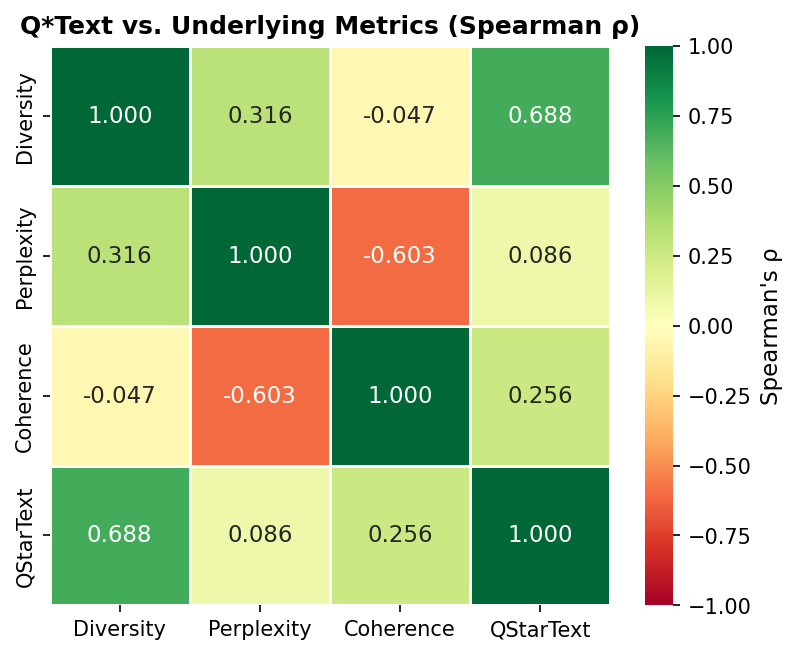

In [20]:
corr_all = df[['Diversity', 'Perplexity', 'Coherence', 'QStarText']].dropna().corr(method='spearman')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr_all, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman's ρ"})
ax.set_title('Q*Text vs. Underlying Metrics (Spearman ρ)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'qstartext_intercorrelation.png', dpi=300, bbox_inches='tight')
plt.show()